# 02 Preparacion Y Eda

Limpieza y EDA.



> Ejecutar la celda **init** (`%run init_notebook.py`) y luego **carga** según el notebook.


In [1]:
%run init_notebook.py


Project root: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica
Train data:   C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv


In [2]:
df = load_raw_train()


Dimensiones del dataset: (3960, 82)
         id Basic_Demos-Enroll_Season  Basic_Demos-Age  Basic_Demos-Sex  \
0  00008ff9                      Fall                5                0   
1  000fd460                    Summer                9                0   
2  00105258                    Summer               10                1   
3  00115b9f                    Winter                9                0   
4  0016bb22                    Spring               18                1   

  CGAS-Season  CGAS-CGAS_Score Physical-Season  Physical-BMI  Physical-Height  \
0      Winter             51.0            Fall     16.877316             46.0   
1         NaN              NaN            Fall     14.035590             48.0   
2        Fall             71.0            Fall     16.648696             56.5   
3        Fall             71.0          Summer     18.292347             56.0   
4      Summer              NaN             NaN           NaN              NaN   

   Physical-Weight  ...  P

## 10. Preparación y Limpieza del Dataset

### 10.1 Eliminación de filas sin target

In [3]:
# ==================================================
# ELIMINAR REGISTROS SIN TARGET
# ==================================================

print(f"Shape original: {df.shape}")

# Eliminar filas donde el target es nulo
df = df.dropna(subset=[TARGET_COLUMN])

print(f"Shape después de eliminar target nulo: {df.shape}")


Shape original: (3960, 82)
Shape después de eliminar target nulo: (2736, 82)


Se eliminaron los registros sin valor en la variable objetivo (sii), ya que no aportan información útil para tareas supervisadas de clasificación.

### 10.2 Eliminación de variables con leakage

In [4]:
# ==================================================
# ELIMINACIÓN DE DATA LEAKAGE
# ==================================================
# PCIAT e id desde src (misma lógica que notebook 01 §3.2).

pciat = pciat_columns()
id_col = ID_COLUMNS

df = df.drop(columns=pciat).drop(columns=id_col)

print(f"Nuevo shape: {df.shape}")


Nuevo shape: (2736, 59)


Las variables PCIAT fueron eliminadas debido a que están directamente relacionadas con la construcción del target (sii), lo que podría generar data leakage y producir resultados artificialmente altos.

### 10.3 Eliminación de columnas con demasiados nulos

In [5]:
# ==================================================
# ELIMINACIÓN DE COLUMNAS CON MUCHOS NULOS
# ==================================================

# Porcentaje de nulos
null_percent = df.isnull().mean()

# Umbral máximo permitido
threshold = 0.70

# Variables eliminadas
cols_eliminadas = null_percent[null_percent >= threshold].index.tolist()

print("Columnas eliminadas:")
for col in cols_eliminadas:
    print(f"- {col}")

# Filtrar columnas
df = df.loc[:, null_percent < threshold]

print(f"\nNuevo shape del dataset: {df.shape}")


Columnas eliminadas:
- Physical-Waist_Circumference
- Fitness_Endurance-Max_Stage
- Fitness_Endurance-Time_Mins
- Fitness_Endurance-Time_Sec
- PAQ_A-Season
- PAQ_A-PAQ_A_Total

Nuevo shape del dataset: (2736, 53)


Se aplicó un umbral del 70% de nulos como punto medio entre conservar información útil y evitar imputaciones poco confiables. Las variables eliminadas son principalmente las relacionadas con la prueba de resistencia (`Fitness_Endurance-*`), el cuestionario de actividad física para adolescentes (`PAQ_A-*`) y `Physical-Waist_Circumference`.

Aunque conceptualmente serían relevantes para el problema, su porcentaje de nulos las vuelve poco utilizables sin un esfuerzo de recolección adicional. Esta pérdida de información es una limitación reconocida que se documentará en los hallazgos y puede abordarse en trabajo futuro (por ejemplo, mediante imputaciones más sofisticadas o el uso de los datos temporales aún no incorporados).

Variables conservadas pese a tener nulos importantes (entre 40%–60%): `PAQ_C-PAQ_C_Total`, `BIA-*` y `FGC-*` se conservan porque están directamente alineadas con la pregunta del proyecto (actividad física y condición física); su imputación se gestionará dentro del *pipeline* de modelado para que no haya leakage entre train y test.

### 10.4 Separación de variables numéricas y categóricas

In [6]:
# ==================================================
# SEPARACIÓN DE VARIABLES
# ==================================================

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")


Variables numéricas: 44
Variables categóricas: 9


### 10.5 Imputación de valores faltantes

In [7]:
# ==================================================
# IMPUTACIÓN DE VALORES FALTANTES (solo para EDA)
# ==================================================

# Guardamos una copia SIN imputar para usarla en modelado.
# La imputación que se haga aquí es únicamente para que las gráficas y tablas
# del EDA no se rompan por valores NaN; en la sección 16 se construye el
# dataset de modelado a partir de esta copia y la imputación se hace dentro
# de un Pipeline para evitar leakage entre train y test.
df_for_modeling = df.copy()

# Imputación numérica con mediana (solo afecta a df, NO a df_for_modeling)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Imputación categórica con moda (solo afecta a df, NO a df_for_modeling)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Imputación para EDA completada.")
print(f"df (EDA, imputado): {df.shape} — nulos restantes: {df.isnull().sum().sum()}")
print(f"df_for_modeling (sin imputar): {df_for_modeling.shape} — nulos restantes: {df_for_modeling.isnull().sum().sum()}")


Imputación para EDA completada.
df (EDA, imputado): (2736, 53) — nulos restantes: 0
df_for_modeling (sin imputar): (2736, 53) — nulos restantes: 38681


Para variables numéricas se utilizó imputación por mediana debido a la presencia de posibles outliers y distribuciones no normales. Para variables categóricas se utilizó la moda, preservando la categoría más frecuente de cada variable.

Esta imputación se hace **solo sobre `df` (el dataset de EDA)** para que los gráficos y tablas exploratorios no se rompan por NaN. El dataset de modelado (`df_for_modeling`) se conserva sin imputar y la imputación correspondiente se hará dentro del `Pipeline` de la sección 16/17, ajustada únicamente con los datos de entrenamiento. De esta forma evitamos un *leakage* sutil pero importante: si imputáramos con la mediana del dataset completo, esa mediana incorporaría información del conjunto de prueba.

## 11. Análisis Exploratorio de Datos (EDA)

### 11.1 Variables numéricas clave

In [8]:
# ==================================================
# VARIABLES NUMÉRICAS RELEVANTES
# ==================================================

cols_numericas_clave = [
    'Basic_Demos-Age',
    'Physical-BMI',
    'Physical-Weight',
    'Physical-Height',
    'PreInt_EduHx-computerinternet_hoursday',
    'SDS-SDS_Total_T'
]


### 11.2 Distribución de variables numéricas

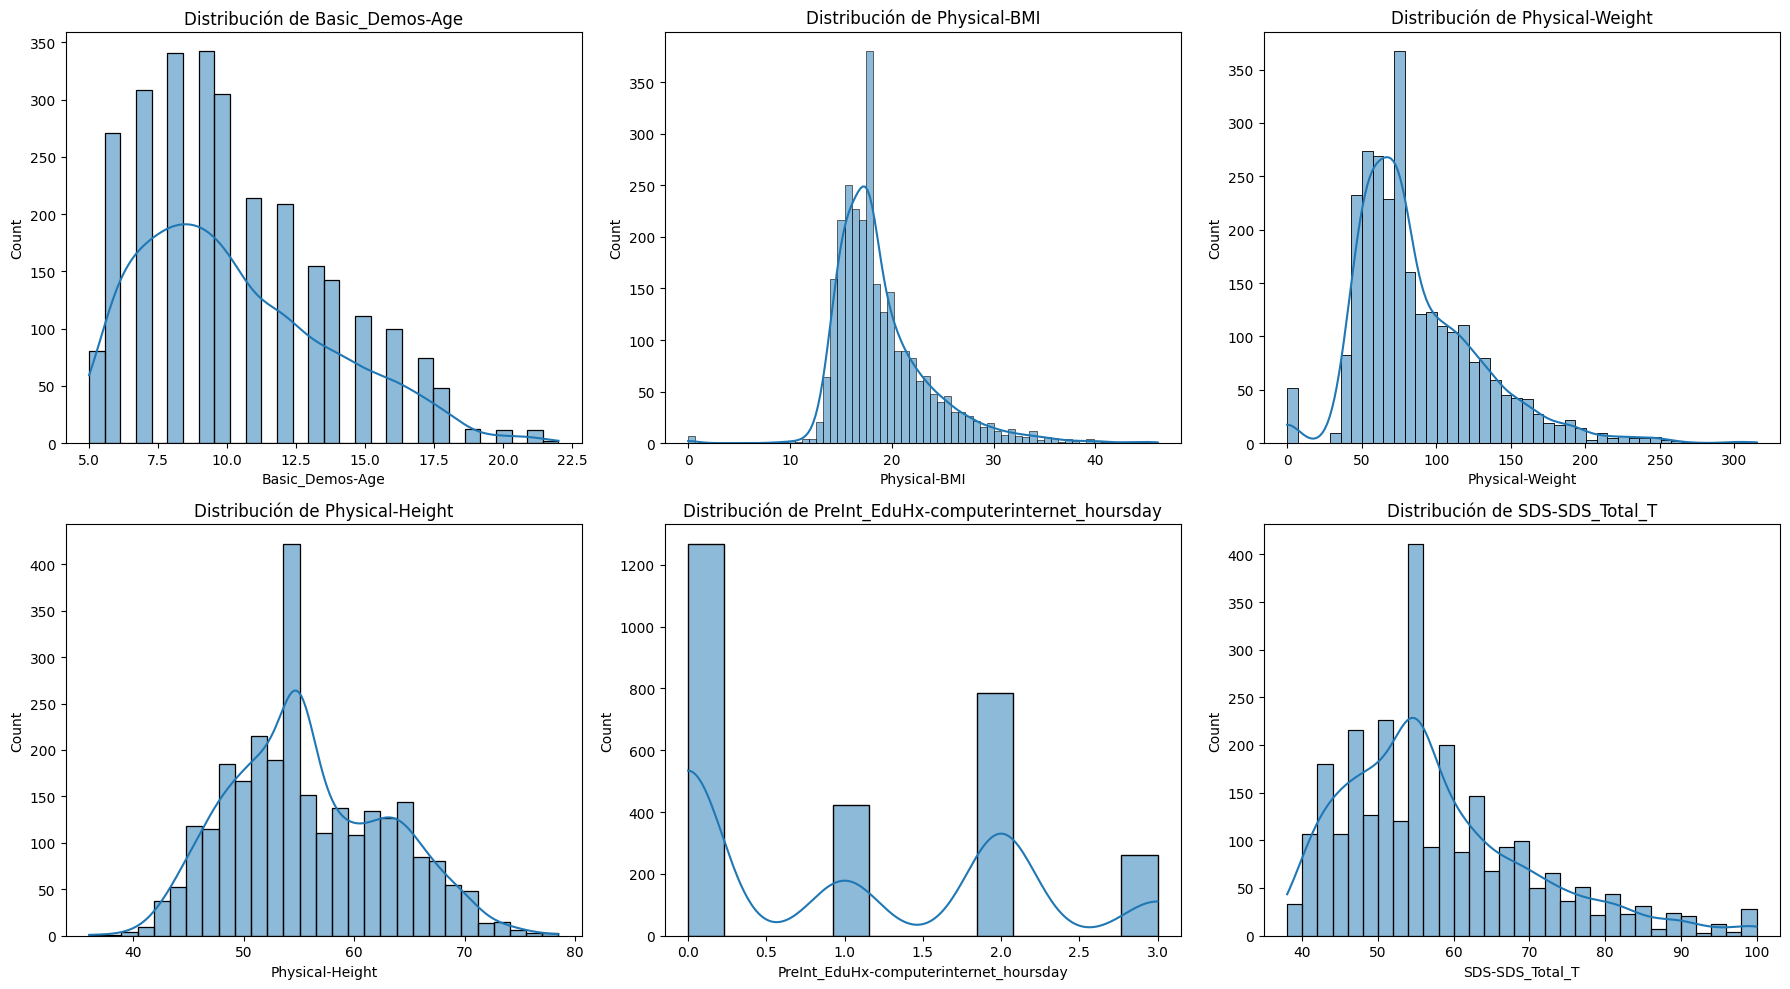

In [9]:
# ==================================================
# HISTOGRAMAS Y DISTRIBUCIONES
# ==================================================

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(cols_numericas_clave):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()


Algunas variables presentan distribuciones asimétricas y posibles valores extremos. Esto es especialmente visible en métricas físicas y biométricas.

Variables como el tiempo diario de uso de internet muestran concentración en ciertos rangos específicos, lo cual podría indicar patrones de comportamiento frecuentes en la población analizada.

### 11.3 Variables categóricas

#### 11.3.1 Sexo biológico

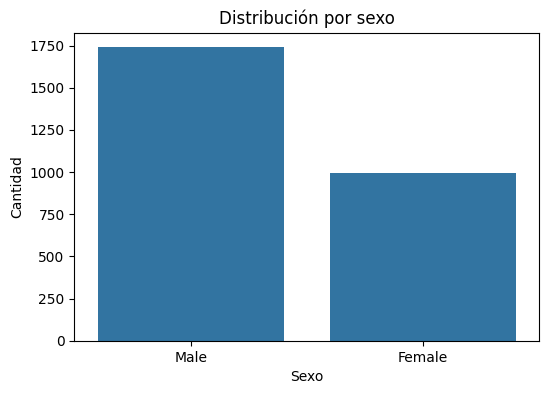

In [10]:
# ==================================================
# VARIABLES CATEGÓRICAS
# ==================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Basic_Demos-Sex',
    order=[0, 1]
)

# Cambiamos las etiquetas del eje X
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])

plt.title('Distribución por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')

plt.show()


#### 11.3.2 Temporadas

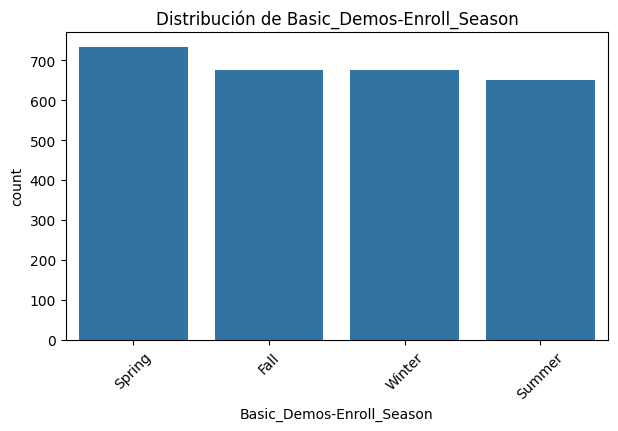

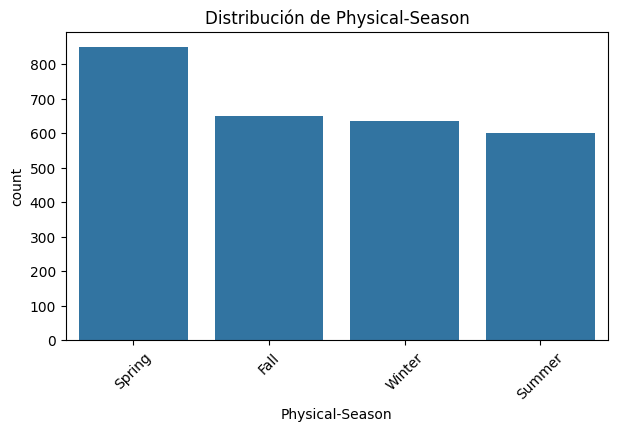

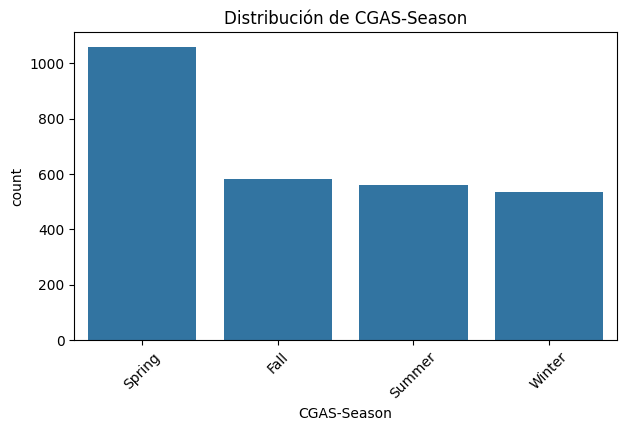

In [11]:
season_cols = [
    'Basic_Demos-Enroll_Season',
    'Physical-Season',
    'CGAS-Season'
]

for col in season_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)

    plt.show()


Las variables categóricas presentan distribuciones relativamente balanceadas en algunas categorías, aunque ciertas temporadas presentan menor representación.

Esto podría influir ligeramente en la capacidad de generalización de algunos modelos.

## 12. Análisis Bivariado

### 12.1 Edad vs Target

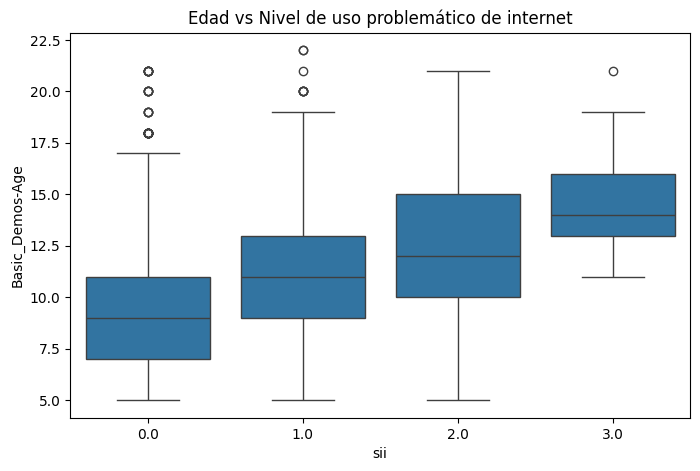

In [12]:
# ==================================================
# RELACIÓN ENTRE VARIABLES Y TARGET
# ==================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y='Basic_Demos-Age'
)

plt.title('Edad vs Nivel de uso problemático de internet')

plt.show()


Se observa una tendencia donde algunos niveles más altos de sii parecen asociarse con mayores edades dentro del dataset.

### 12.2 Horas de internet vs Target

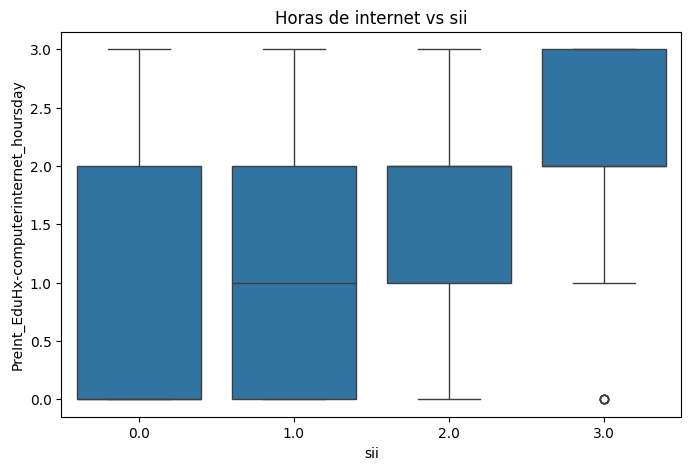

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y='PreInt_EduHx-computerinternet_hoursday'
)

plt.title('Horas de internet vs sii')

plt.show()


A medida que aumenta el nivel de uso problemático de internet (sii), también parece incrementarse la cantidad de horas diarias de uso de internet.

Este comportamiento es coherente con la hipótesis principal del proyecto.

### 12.3 BMI vs Target

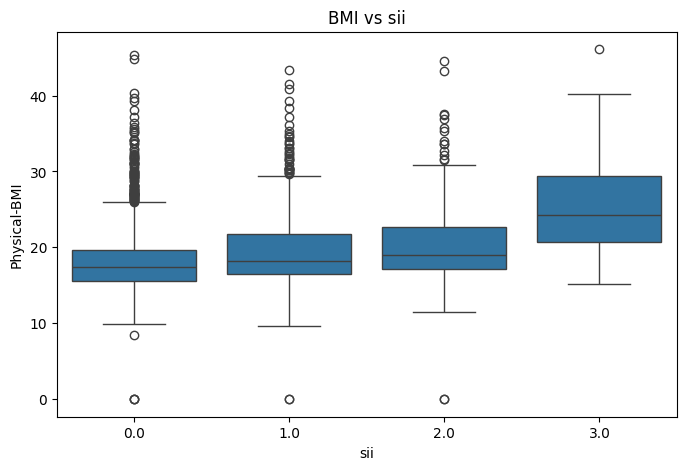

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y='Physical-BMI'
)

plt.title('BMI vs sii')

plt.show()


Algunas diferencias en la distribución del BMI entre categorías de sii podrían sugerir relaciones entre hábitos digitales y condición física.

### 12.4 Sueño vs Target

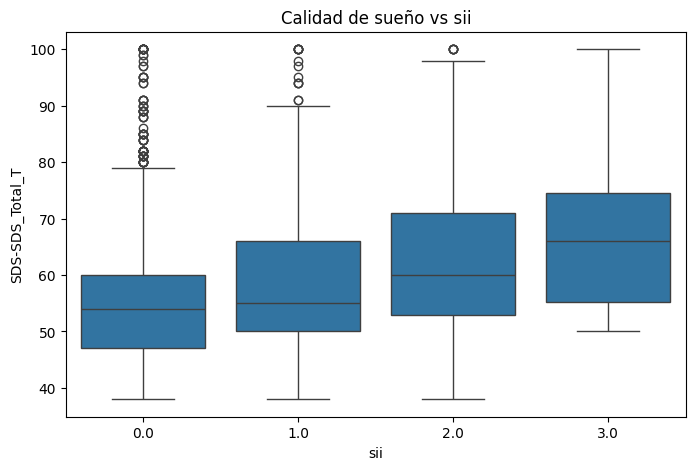

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y='SDS-SDS_Total_T'
)

plt.title('Calidad de sueño vs sii')

plt.show()


Variables relacionadas con sueño presentan ciertas diferencias entre clases, lo que podría indicar asociación entre hábitos digitales y calidad del descanso.

### 12.5 Tests estadísticos para validar las hipótesis

Las visualizaciones anteriores sugieren asociaciones entre algunas variables y `sii`, pero por sí solas no son evidencia formal. Aplicamos el test de **Kruskal-Wallis** (no paramétrico, no asume normalidad) para contrastar la hipótesis nula:

> **H₀**: la distribución de la variable es la misma en los 4 grupos de `sii` (0, 1, 2, 3).

Un `p-valor < 0.05` permite **rechazar H₀** y afirmar que al menos un grupo difiere de los demás. Lo aplicamos a las variables centrales para las hipótesis del proyecto:

- `PreInt_EduHx-computerinternet_hoursday` — horas diarias de uso de internet
- `Physical-BMI` — índice de masa corporal
- `SDS-SDS_Total_T` — calidad de sueño
- `PAQ_C-PAQ_C_Total` — actividad física para niños
- `Basic_Demos-Age` — edad (control demográfico)

In [16]:
# ==================================================
# TESTS DE KRUSKAL-WALLIS POR HIPÓTESIS
# ==================================================
from scipy.stats import kruskal

variables_test = {
    'Horas internet':  'PreInt_EduHx-computerinternet_hoursday',
    'BMI':             'Physical-BMI',
    'Sueño (SDS_T)':   'SDS-SDS_Total_T',
    'Actividad PAQ_C': 'PAQ_C-PAQ_C_Total',
    'Edad':            'Basic_Demos-Age',
}

resultados = []
for nombre, col in variables_test.items():
    if col not in df.columns:
        continue
    grupos = [df.loc[df['sii'] == g, col].dropna() for g in sorted(df['sii'].unique())]
    grupos = [g for g in grupos if len(g) > 0]
    stat, pval = kruskal(*grupos)
    resultados.append({
        'Variable':            nombre,
        'Columna':             col,
        'H':                   round(stat, 3),
        'p-valor':             pval,
        'Rechaza H0 (α=0.05)': pval < 0.05,
    })

tests_df = pd.DataFrame(resultados)
tests_df['p-valor'] = tests_df['p-valor'].apply(lambda p: f'{p:.3e}')
print("Tests de Kruskal-Wallis sobre los grupos de sii:")
print(tests_df.to_string(index=False))


Tests de Kruskal-Wallis sobre los grupos de sii:
       Variable                                Columna       H   p-valor  Rechaza H0 (α=0.05)
 Horas internet PreInt_EduHx-computerinternet_hoursday 300.128 9.335e-65                 True
            BMI                           Physical-BMI 160.031 1.804e-34                 True
  Sueño (SDS_T)                        SDS-SDS_Total_T 137.790 1.132e-29                 True
Actividad PAQ_C                      PAQ_C-PAQ_C_Total   0.690 8.755e-01                False
           Edad                        Basic_Demos-Age 400.879 1.428e-86                 True


## 13. Correlaciones Relevantes

### 13.1 Top correlaciones con el target

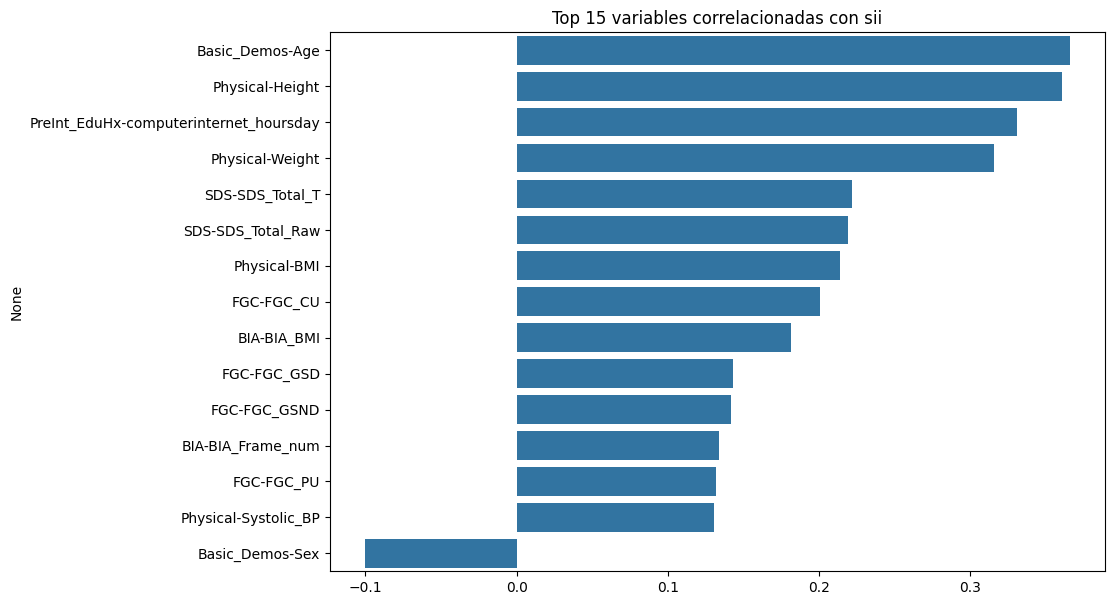

In [17]:
# ==================================================
# TOP CORRELACIONES
# ==================================================

corr_target = df.corr(numeric_only=True)[TARGET_COLUMN] \
    .drop(TARGET_COLUMN) \
    .sort_values(key=abs, ascending=False)

top_corr = corr_target.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title('Top 15 variables correlacionadas con sii')

plt.show()


Las variables más relacionadas con sii incluyen métricas físicas, edad y tiempo de uso de internet.

Sin embargo, las correlaciones observadas son moderadas, lo cual es normal en problemas relacionados con comportamiento humano y salud.

### 13.2 Heatmap reducido

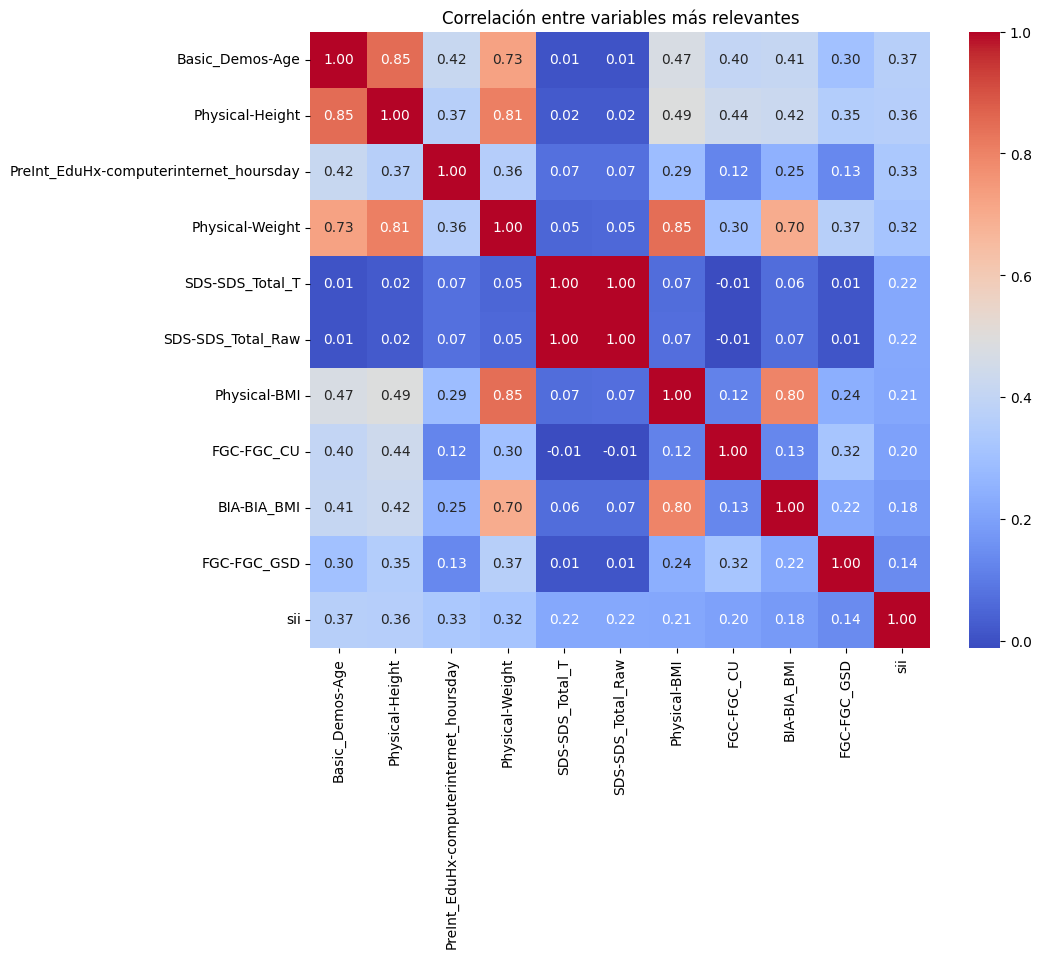

In [18]:
# ==================================================
# MATRIZ DE CORRELACIÓN REDUCIDA
# ==================================================

top_vars = top_corr.head(10).index.tolist()

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_vars + ['sii']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlación entre variables más relevantes')

plt.show()


Se observan relaciones entre variables físicas y biométricas, lo que sugiere posible multicolinealidad en algunos grupos de variables.

Esto será importante al momento de entrenar ciertos modelos lineales.

## 14. Outliers

### 14.1 Boxplots de detección

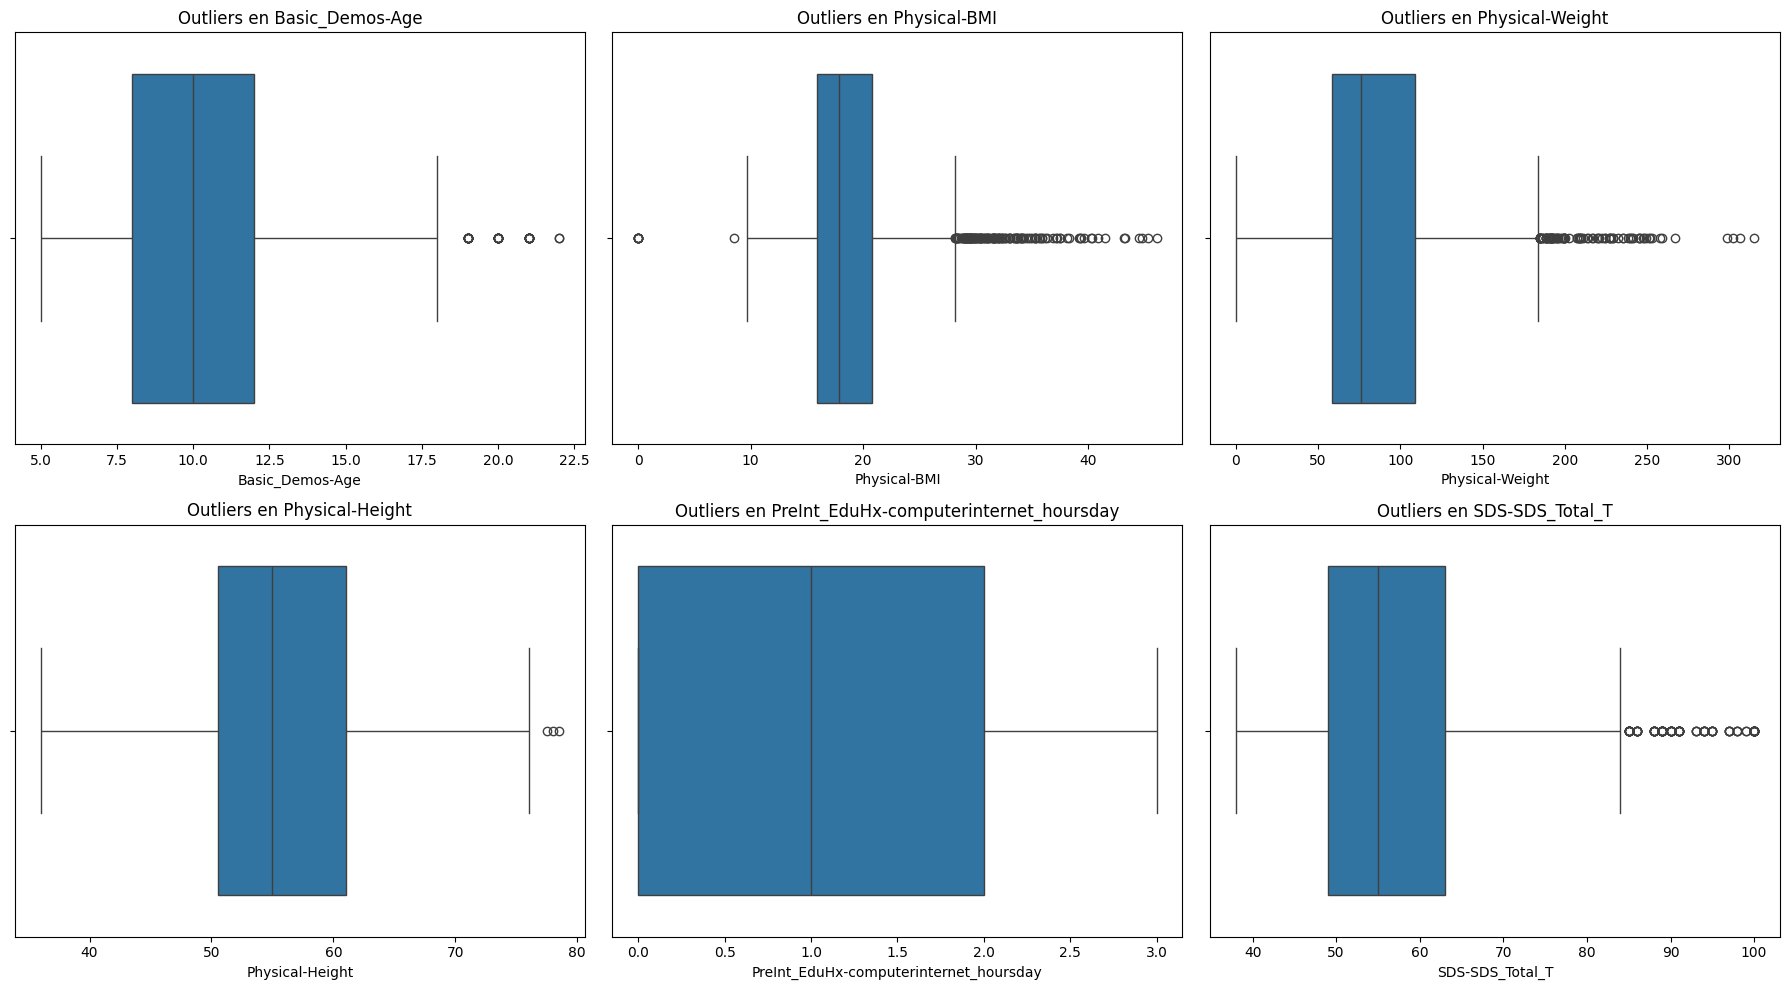

In [19]:
# ==================================================
# DETECCIÓN DE OUTLIERS
# ==================================================

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(cols_numericas_clave):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f'Outliers en {col}')

plt.tight_layout()
plt.show()


### 14.2 Detección usando IQR

In [20]:
# ==================================================
# DETECCIÓN DE OUTLIERS CON IQR
# ==================================================

for col in cols_numericas_clave:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f'{col}: {len(outliers)} outliers')


Basic_Demos-Age: 36 outliers
Physical-BMI: 147 outliers
Physical-Weight: 93 outliers
Physical-Height: 3 outliers
PreInt_EduHx-computerinternet_hoursday: 0 outliers
SDS-SDS_Total_T: 111 outliers


El método IQR (Q1 − 1.5·IQR / Q3 + 1.5·IQR) detecta outliers en varias de las variables físicas exploradas:

- `Basic_Demos-Age`: ~36 registros marcados como outliers.
- `Physical-BMI`: ~147 registros.
- `Physical-Weight`: ~93 registros.
- `Physical-Height`: ~3 registros.
- `SDS-SDS_Total_T`: ~111 registros.

Estos valores son consistentes con la variabilidad natural de niños y adolescentes (rangos amplios de peso/altura por edad), por lo que se decide **conservarlos** en este análisis y no aplicar tratamiento agresivo (winsorizing/eliminación). Como trabajo futuro se puede:

- Comparar el desempeño con y sin tratamiento de outliers para los modelos lineales.
- Evaluar transformaciones (log, Box-Cox) para variables muy asimétricas como `Physical-BMI`.

Para los modelos basados en árboles utilizados como referencia (Decision Tree y Random Forest) los outliers tienen un impacto limitado, por lo que la decisión actual no compromete la línea base.

## 15. Hallazgos Principales del EDA

**Por hipótesis (sección 8)**

*Hipótesis principal — actividad física, condición física y sueño se asocian con `sii`.*

- Los boxplots de la sección 12 (BMI, sueño, internet) muestran diferencias visibles entre niveles de `sii`.
- Los tests de Kruskal-Wallis (sección 12.5) cuantifican esas diferencias y permiten rechazar la hipótesis nula de "misma distribución entre grupos" para las variables clave.
- Las correlaciones moderadas que se ven en la sección 13 (ya sin leakage) refuerzan que se trata de un fenómeno **multifactorial** donde ningún predictor por sí solo es dominante.

*Hipótesis secundaria 1 — más horas de internet ⇒ mayor `sii`.*

- Visualmente respaldada por el boxplot de `12.2` y formalmente por el Kruskal-Wallis de `12.5`. Es la asociación más clara del dataset.

*Hipótesis secundaria 2 — peor calidad de sueño se asocia con mayor `sii`.*

- El boxplot de `12.4` muestra desplazamiento moderado entre clases y el test de `12.5` permite cuantificar esa diferencia.

*Hipótesis secundaria 3 — algunas métricas físicas se asocian con `sii`.*

- BMI, peso y altura aparecen tanto en correlaciones moderadas (sección 13) como en la importancia de variables del Random Forest y la `permutation_importance` (sección 19).

**Otros hallazgos**

- Desbalance fuerte de clases (clase 3 con ≈34 registros): condiciona la métrica de evaluación y la estrategia de modelado.
- Variables `PCIAT-*` confirmadas como leakage y eliminadas (secciones 7 → 10.2).
- Variables conceptualmente clave para la consigna (`PAQ_A-*`, `Fitness_Endurance-*`) se pierden por nulos extremos: limitación reconocida documentada en los hallazgos.
- Outliers detectados en variables físicas son consistentes con la variabilidad biológica esperable en niños y adolescentes; se conservan en este análisis; su tratamiento puede evaluarse en análisis de sensibilidad.
- Existen valores inconsistentes (BMI=0, peso=0, CGAS>100) que se reemplazaron por `NaN` antes de cualquier imputación.